# Pokemon-style clone: networked PvP creature battles
* this is it - the final lesson of the whole game-development arc that started all the way back in lesson 27!
* lessons 37 and 38 built a complete SINGLE-PLAYER monster-collecting game: original creatures with types and moves, a turn-based battle system with speed-based turn order, a walkable overworld with wild encounters and trainers, all wrapped up into a capstone
* lessons 33 and 34, way back before that little detour, built the generic multiplayer NETWORKING side of things: sockets, an authoritative server, `asyncio.start_server`, broadcasting state to keep every connected client in sync
* this lesson fuses BOTH halves together: two REAL players (well, two simulated clients standing in for them, same as lesson 34) connect to one server and battle their OWN creatures against each other - an actual player-vs-player (PvP) fight, refereed by an authoritative server so neither side can cheat
* we rebuild a small, self-contained creature/type/move system from scratch here (we don't need lesson 37's full depth for this lesson - the POINT here is the networking, not re-deriving battle mechanics we already built), then bolt lesson 34's exact server/client pattern onto it

## rebuilding a small, lean creature/type/move system
* recap lesson 37's idea, kept deliberately lean: a handful of TYPES, a small effectiveness chart, a couple of MOVES per creature (each with a power, an accuracy, and a type), and a `Creature` with hp/speed/moves
* we only need TWO creatures for this lesson's demo, so we keep the roster tiny on purpose
* `random.seed(42)` right away (same habit as lesson 32/37) - a fixed seed means every damage roll in this notebook comes out identically every time we re-run it top to bottom, so this lesson stays 100% reproducible

In [1]:
import random
from dataclasses import dataclass, field

random.seed(42)  # fixed seed - every "random" damage roll below becomes fully reproducible, run after run

# a tiny type effectiveness chart - just 3 types is plenty to show the mechanic off (recap lesson 37's idea, kept lean here)
# key = (attacking_move_type, defending_creature_type), value = damage multiplier
TYPE_CHART = {
    ("fire", "grass"): 2.0,   # fire burns grass - super effective
    ("grass", "water"): 2.0,  # grass soaks up water - super effective
    ("water", "fire"): 2.0,   # water douses fire - super effective
    ("grass", "fire"): 0.5,   # the reverse matchups are all NOT very effective
    ("water", "grass"): 0.5,
    ("fire", "water"): 0.5,
}


def effectiveness(attack_type, defend_type):
    # .get() with a default of 1.0 means "neutral" for any matchup not explicitly listed (e.g. a normal-type move, or a mirror match)
    return TYPE_CHART.get((attack_type, defend_type), 1.0)


@dataclass
class Move:
    name: str
    move_type: str   # what type this MOVE is, e.g. "fire" - used to look up effectiveness against the defender's type
    power: int        # the move's base power - bigger number, bigger hit
    accuracy: float   # 0.0-1.0 chance to actually land - 1.0 means it always hits


@dataclass
class Creature:
    name: str
    creature_type: str   # what type this CREATURE is, e.g. "water" - matters when IT gets attacked
    max_hp: int
    hp: int
    speed: int            # higher speed creature gets to move first each battle (recap lesson 37/38's turn order rule)
    moves: list           # a list of Move objects this creature knows

    def to_dict(self):
        # a small, JSON-friendly snapshot of just the bits a client needs to SEE - never the whole object, keeps messages small
        return {"name": self.name, "type": self.creature_type, "hp": self.hp, "max_hp": self.max_hp}


def make_emberling():
    # a fresh instance every time this is called - important! two battles must never accidentally share one mutable Creature
    return Creature(
        name="Emberling", creature_type="fire", max_hp=60, hp=60, speed=12,
        moves=[
            Move(name="Ember Jab", move_type="fire", power=25, accuracy=1.0),
            Move(name="Tackle", move_type="normal", power=15, accuracy=1.0),
        ],
    )


def make_aqualing():
    return Creature(
        name="Aqualing", creature_type="water", max_hp=60, hp=60, speed=10,
        moves=[
            Move(name="Water Splash", move_type="water", power=25, accuracy=1.0),
            Move(name="Tackle", move_type="normal", power=15, accuracy=1.0),
        ],
    )


# a quick sanity check before we build any networking on top of this: Aqualing's Water Splash should be SUPER effective on Emberling
sample_emberling = make_emberling()
print("Water Splash (water) vs Emberling (fire) multiplier:", effectiveness("water", sample_emberling.creature_type))
print("Ember Jab (fire) vs an Aqualing (water) multiplier:  ", effectiveness("fire", "water"))
print("Emberling is faster than Aqualing?", make_emberling().speed > make_aqualing().speed, "- so Emberling opens the fight")

Water Splash (water) vs Emberling (fire) multiplier: 2.0
Ember Jab (fire) vs an Aqualing (water) multiplier:   0.5
Emberling is faster than Aqualing? True - so Emberling opens the fight


## the authoritative battle state - recap lesson 33's whole point
* recap lesson 33's core lesson: if each CLIENT calculated its own damage and just told the server "I dealt 40 damage", a modified/cheating client could claim to deal ANY damage it likes, or just claim victory outright - there is no way for anyone else to verify it
* so exactly like lesson 34's world state, the SERVER here holds the ONE true, authoritative `BATTLE` dict: both creatures' real hp, whose turn it really is, and the running battle log
* a client only ever gets to send a REQUEST like `{"type": "choose_move", "move_index": 0}` - meaning "I'd like to use my first move" - it never gets to say what happens as a result
* the SERVER is the only code that ever calls `calculate_damage()` and updates any creature's `hp` - it then broadcasts the real, true outcome to BOTH players after every single action, so neither player's screen can ever drift from the truth (or be lied to by the other player's client)

In [2]:
import asyncio
import json

# --- the server's ONE authoritative battle state - only server-side code below is ever allowed to change this ---
BATTLE = {
    "players": {},   # player_id -> {"creature": Creature, "writer": StreamWriter} - filled in as people connect
    "order": [],      # turn order, decided once both players are in, e.g. ["player1", "player2"]
    "turn": None,     # whose turn it REALLY is right now, according to the server
    "log": [],        # every battle log line so far, in order - the full authoritative history of the fight
    "winner": None,   # set once the battle ends
    "over": False,    # True once someone has won
}
connections = {}  # player_id -> StreamWriter, everyone we currently need to broadcast updates to


def calculate_damage(move, defender):
    """THE authoritative damage calculation - this is the one and only place damage is ever decided, server-side only."""
    if random.random() > move.accuracy:  # a miss - accuracy 1.0 here means this branch never actually triggers, but the check stays honest
        return 0, False
    multiplier = effectiveness(move.move_type, defender.creature_type)
    # a small random swing (recap lesson 32's damage formula) so identical moves don't ALWAYS deal the exact same number
    raw_damage = move.power * multiplier * random.uniform(0.85, 1.15)
    return max(1, int(raw_damage)), True  # max(1, ...) so a hit always does at LEAST 1 damage, never a weird 0


async def broadcast_battle_state():
    """Send the current, REAL battle state to every connected client - exactly lesson 34's broadcast pattern."""
    message = (json.dumps({
        "type": "battle_state",
        "player1": BATTLE["players"]["player1"]["creature"].to_dict() if "player1" in BATTLE["players"] else None,
        "player2": BATTLE["players"]["player2"]["creature"].to_dict() if "player2" in BATTLE["players"] else None,
        "turn": BATTLE["turn"],
        "log": BATTLE["log"][-1] if BATTLE["log"] else "",  # just the LAST action's log line - keeps each message small
        "winner": BATTLE["winner"],
        "over": BATTLE["over"],
    }) + "\n").encode()
    for writer in connections.values():
        writer.write(message)
        await writer.drain()


async def process_move_request(player_id, move_index):
    """Handles one 'choose_move' request - THIS function is the anti-cheat gate lesson 33 was all about."""
    if BATTLE["over"]:
        return  # the fight is already decided, nothing more to do - ignore any late requests from anyone

    # --- THE critical check: only accept a move from whoever's turn the SERVER thinks it really is ---
    if player_id != BATTLE["turn"]:
        print(f"[server] rejected a move from {player_id} - it is currently {BATTLE['turn']}'s turn, ignoring, no state change")
        return  # we do NOT broadcast anything here - the battle state genuinely did not change, there's nothing new to tell anyone

    mover_id = player_id
    opponent_id = "player2" if mover_id == "player1" else "player1"
    mover = BATTLE["players"][mover_id]["creature"]
    opponent = BATTLE["players"][opponent_id]["creature"]
    move = mover.moves[move_index]

    damage, hit = calculate_damage(move, opponent)  # the ONE real, true damage calculation for this action
    if hit:
        opponent.hp = max(0, opponent.hp - damage)
        multiplier = effectiveness(move.move_type, opponent.creature_type)
        effect_text = " - super effective!" if multiplier > 1 else (" - not very effective..." if multiplier < 1 else "")
        BATTLE["log"].append(f"{mover.name} used {move.name}! dealt {damage} damage to {opponent.name}{effect_text}")
    else:
        BATTLE["log"].append(f"{mover.name} used {move.name}, but it missed!")

    if opponent.hp <= 0:
        BATTLE["over"] = True
        BATTLE["winner"] = mover_id
        BATTLE["log"].append(f"{opponent.name} fainted! {mover_id} wins the battle!")
    else:
        BATTLE["turn"] = opponent_id  # simple alternating turns once the fight is underway - speed only decided who opened

    await broadcast_battle_state()  # tell BOTH players the real, true outcome of this action


async def handle_client(reader, writer):
    """One coroutine per connected client, exactly lesson 34's shape - waits for exactly 2 players, then referees."""
    if "player1" not in BATTLE["players"]:
        player_id, creature = "player1", make_emberling()
    elif "player2" not in BATTLE["players"]:
        player_id, creature = "player2", make_aqualing()
    else:
        # this lean main-lesson server is a strict 1v1 duel only - a 3rd connection is politely turned away here
        # (exercise 4 below builds a fancier version of this server that DOES allow spectators)
        writer.write((json.dumps({"type": "error", "message": "battle is already full"}) + "\n").encode())
        await writer.drain()
        writer.close()
        return

    BATTLE["players"][player_id] = {"creature": creature, "writer": writer}
    connections[player_id] = writer
    writer.write((json.dumps({"type": "welcome", "player_id": player_id}) + "\n").encode())
    await writer.drain()

    if len(BATTLE["players"]) == 2 and not BATTLE["order"]:
        # both players are in - decide turn order by speed (recap lesson 37/38), then kick the battle off
        p1_speed = BATTLE["players"]["player1"]["creature"].speed
        p2_speed = BATTLE["players"]["player2"]["creature"].speed
        BATTLE["order"] = ["player1", "player2"] if p1_speed >= p2_speed else ["player2", "player1"]
        BATTLE["turn"] = BATTLE["order"][0]
        BATTLE["log"].append(f"the battle begins! {BATTLE['order'][0]}'s creature is faster and moves first")
        await broadcast_battle_state()

    try:
        while True:
            line = await reader.readline()  # recap lesson 33/34 - readline() gives us free message framing over TCP
            if not line:  # empty read = the client disconnected
                break
            request = json.loads(line)
            if request["type"] == "choose_move":
                await process_move_request(player_id, request.get("move_index", 0))
            # any other message type is simply ignored here - this lean main server only understands one action
    finally:
        connections.pop(player_id, None)  # basic cleanup - handling a mid-battle disconnect gracefully is exercise 3 below


battle_server = await asyncio.start_server(handle_client, "127.0.0.1", 0)
battle_port = battle_server.sockets[0].getsockname()[1]
print(f"PvP battle server listening on 127.0.0.1:{battle_port}, waiting for exactly 2 players to connect...")

PvP battle server listening on 127.0.0.1:38167, waiting for exactly 2 players to connect...


## a `BattleClient` helper - recap lesson 34's `SimClient` shape
* same idea as lesson 34's `SimClient`: `.connect()` opens the connection and starts a background `asyncio.create_task()` listener that keeps recording every broadcast into `.history`
* a `.choose_move()` method sends a REQUEST only - recap the whole point above, the client never decides the outcome itself
* `.latest_state` gives us the most recent `battle_state` broadcast this client has seen - what that player's screen would actually be showing right now

In [3]:
class BattleClient:
    """Stands in for one player's game client - connects, listens for battle broadcasts in the background, sends move requests."""

    def __init__(self, name):
        self.name = name
        self.history = []  # every broadcast this client has ever received, in order - "everything this player has seen"

    async def connect(self):
        self.reader, self.writer = await asyncio.open_connection("127.0.0.1", battle_port)
        welcome = json.loads(await self.reader.readline())
        self.player_id = welcome["player_id"]
        self._listen_task = asyncio.create_task(self._listen_forever())  # background task, keeps running independently

    async def _listen_forever(self):
        """Runs in the background for this client's whole lifetime, recording every broadcast as it arrives."""
        while True:
            line = await self.reader.readline()
            if not line:
                break
            self.history.append(json.loads(line))

    async def choose_move(self, move_index):
        """Send a move REQUEST - just a wish, not a fact. The server decides what actually happens."""
        self.writer.write((json.dumps({"type": "choose_move", "move_index": move_index}) + "\n").encode())
        await self.writer.drain()

    async def disconnect(self):
        self.writer.close()
        await asyncio.sleep(0.05)  # give the server a moment to notice and process the disconnect

    @property
    def latest_state(self):
        """The most recent 'battle_state' broadcast this client saw - skips over other message types like 'welcome'."""
        for entry in reversed(self.history):
            if entry["type"] == "battle_state":
                return entry
        return None


print("BattleClient ready - connects, listens for the referee's broadcasts in the background, and can request moves")

BattleClient ready - connects, listens for the referee's broadcasts in the background, and can request moves


## the battle begins - two players connect
* `dana` and `sam` stand in for two real players, exactly like `alice`/`bob` did in lesson 34
* Dana gets an Emberling, Sam gets an Aqualing - assigned automatically by the server, in connection order
* the little sleeps after connecting give the background listener tasks time to actually receive and record the welcome + battle-start broadcasts before we check `.history` (recap lesson 34's flakiness warning)

In [4]:
dana = BattleClient("Dana")
sam = BattleClient("Sam")

await dana.connect()
await asyncio.sleep(0.05)   # small stagger so the "welcome" messages arrive in a tidy order (not required, just neat)
await sam.connect()
await asyncio.sleep(0.15)   # let both welcomes AND the battle-start broadcast (fires once the 2nd player joins) settle in

print(f"{dana.name} connected as {dana.player_id}, battling with an Emberling")
print(f"{sam.name} connected as {sam.player_id}, battling with an Aqualing")
print("opening battle state:", dana.latest_state)
print("whose turn is it first?", dana.latest_state["turn"], "- the faster creature always opens the fight")

Dana connected as player1, battling with an Emberling
Sam connected as player2, battling with an Aqualing
opening battle state: {'type': 'battle_state', 'player1': {'name': 'Emberling', 'type': 'fire', 'hp': 60, 'max_hp': 60}, 'player2': {'name': 'Aqualing', 'type': 'water', 'hp': 60, 'max_hp': 60}, 'turn': 'player1', 'log': "the battle begins! player1's creature is faster and moves first", 'winner': None, 'over': False}
whose turn is it first? player1 - the faster creature always opens the fight


## round 1 - a couple of scripted turns
* both clients pick moves ALTERNATELY, but notice HOW we decide who acts: we always ask the SERVER's own state (`dana.latest_state["turn"]`) whose turn it really is, never just alternate blindly ourselves
* that's an important habit for any real turn-based multiplayer client: never assume, always check the authoritative state

In [5]:
def whoever_is_up(state):
    # figure out, from the SERVER's own broadcast state, which of our two clients should act next
    return dana if state["turn"] == "player1" else sam


for round_number in range(1, 3):  # play out the opening TWO turns of the fight, one action at a time
    current_state = dana.latest_state           # doesn't matter which client we peek at - both see the identical state
    actor = whoever_is_up(current_state)         # ask the server's own state whose turn it actually is
    await actor.choose_move(0)                   # each creature's signature move: Ember Jab for Emberling, Water Splash for Aqualing
    await asyncio.sleep(0.1)                      # give the broadcast time to land in both clients' histories
    print(f"round {round_number}:", dana.latest_state["log"])

print()
print("battle state after 2 rounds:", dana.latest_state)

round 1: Emberling used Ember Jab! dealt 10 damage to Aqualing - not very effective...


round 2: Aqualing used Water Splash! dealt 45 damage to Emberling - super effective!

battle state after 2 rounds: {'type': 'battle_state', 'player1': {'name': 'Emberling', 'type': 'fire', 'hp': 15, 'max_hp': 60}, 'player2': {'name': 'Aqualing', 'type': 'water', 'hp': 50, 'max_hp': 60}, 'turn': 'player1', 'log': 'Aqualing used Water Splash! dealt 45 damage to Emberling - super effective!', 'winner': None, 'over': False}


## rendering the battle screen
* recap lesson 27's headless pygame setup (`SDL_VIDEODRIVER=dummy`) and lesson 32/37's hp-bar battle screen idea
* nothing new technically here - just `pygame.draw.rect` for the hp bar background/fill/outline and `pygame.font` for labels, then our usual `show_surface()` helper to display it inline

pygame 2.6.1 (SDL 2.28.4, Python 3.11.15)
Hello from the pygame community. https://www.pygame.org/contribute.html


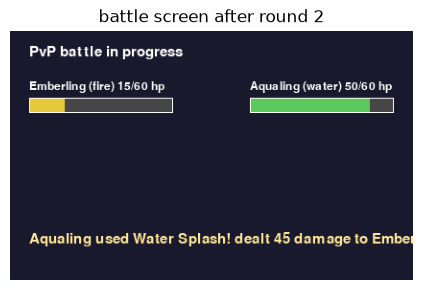

In [6]:
import os

os.environ["SDL_VIDEODRIVER"] = "dummy"  # render off-screen - no real display attached to this notebook environment
os.environ["SDL_AUDIODRIVER"] = "dummy"  # same story for audio - we don't need sound for a battle screenshot anyway

import pygame
import numpy as np
import matplotlib.pyplot as plt

pygame.init()
pygame.font.init()


def show_surface(surface, title=None, figsize=(5, 4)):
    pixel_array = pygame.surfarray.array3d(surface).swapaxes(0, 1)  # pygame is (w, h, c), matplotlib wants (h, w, c)
    plt.figure(figsize=figsize)
    plt.imshow(pixel_array)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()


def draw_battle_screen(state, title_text=None):
    """Draws a simple two-creature battle screen with hp bars, straight from a client's latest battle_state."""
    surface = pygame.Surface((420, 260))
    surface.fill((25, 25, 45))  # a dark battle-arena background
    label_font = pygame.font.SysFont(None, 22)
    small_font = pygame.font.SysFont(None, 18)

    def draw_hp_bar(x, y, creature):
        pygame.draw.rect(surface, (70, 70, 70), (x, y, 150, 16))  # the "empty" background part of the bar
        hp_fraction = max(0, creature["hp"]) / creature["max_hp"]
        # green when healthy, yellow when hurting, red when critical - a classic, readable hp-bar convention
        bar_color = (90, 200, 90) if hp_fraction > 0.5 else ((230, 200, 60) if hp_fraction > 0.2 else (220, 60, 60))
        pygame.draw.rect(surface, bar_color, (x, y, int(150 * hp_fraction), 16))  # the "filled" part, scaled to current hp
        pygame.draw.rect(surface, (255, 255, 255), (x, y, 150, 16), 1)  # a thin outline to frame the bar
        name_label = small_font.render(f"{creature['name']} ({creature['type']}) {creature['hp']}/{creature['max_hp']} hp", True, (255, 255, 255))
        surface.blit(name_label, (x, y - 18))

    draw_hp_bar(20, 70, state["player1"])
    draw_hp_bar(250, 70, state["player2"])

    log_label = label_font.render(state["log"], True, (255, 230, 150))  # the most recent action, front and center
    surface.blit(log_label, (20, 210))

    if title_text:
        title_label = label_font.render(title_text, True, (255, 255, 255))
        surface.blit(title_label, (20, 15))
    return surface


battle_snapshot = draw_battle_screen(dana.latest_state, title_text="PvP battle in progress")
show_surface(battle_snapshot, title="battle screen after round 2", figsize=(5.2, 3.4))

## proving the anti-cheat point, for real this time
* recap lesson 33's whole reason for an authoritative server: a client should NEVER be trusted to decide the outcome of a competitive interaction by itself
* right now it's one specific player's turn - lets have the OTHER player's client try to sneak in a move anyway, exactly like a buggy or deliberately cheating client might
* if the server is doing its job, the battle state must come out COMPLETELY unchanged - no damage dealt, no turn change, nothing

In [7]:
state_before = dict(dana.latest_state)  # a snapshot COPY of the state right before we try to cheat
not_current_player = sam if state_before["turn"] == "player1" else dana
current_player_name = dana.name if state_before["turn"] == "player1" else sam.name

print(f"it is currently {current_player_name}'s turn - lets have {not_current_player.name} try to butt in anyway")

await not_current_player.choose_move(0)  # an OUT-OF-TURN move request - the server should just ignore this entirely
await asyncio.sleep(0.15)                 # give the server plenty of time to (not) do anything about it

state_after = dana.latest_state
print()
print("battle state completely unchanged?", state_before == state_after)
print("turn still correctly belongs to:", state_after["turn"])
print("this is exactly lesson 33's authoritative-server payoff: no client, honest or not, can ever act out of turn")

it is currently Dana's turn - lets have Sam try to butt in anyway

battle state completely unchanged? True
turn still correctly belongs to: player1
this is exactly lesson 33's authoritative-server payoff: no client, honest or not, can ever act out of turn


## finishing the fight
* now lets just let the battle play out to its conclusion, the same way - always asking the server's own state whose turn it is
* and then, the real proof of synchronization (same idea as lesson 34's "do both players agree on the current state?" check): we compare the FULL battle log as seen by both clients independently

In [8]:
while not dana.latest_state["over"]:
    current_state = dana.latest_state
    actor = whoever_is_up(current_state)
    await actor.choose_move(0)
    await asyncio.sleep(0.1)
    print("next action:", dana.latest_state["log"])

print()
print("battle over! winner:", dana.latest_state["winner"])

# gather the FULL battle log as each client independently experienced it
dana_log = [entry["log"] for entry in dana.history if entry["type"] == "battle_state"]
sam_log = [entry["log"] for entry in sam.history if entry["type"] == "battle_state"]

print()
print("the full battle log, as Dana's client saw it:")
for line in dana_log:
    print(" -", line)

print()
print("did both players see the EXACT same battle log, in the exact same order?", dana_log == sam_log)

next action: Emberling used Ember Jab! dealt 13 damage to Aqualing - not very effective...
next action: Emberling fainted! player2 wins the battle!

battle over! winner: player2

the full battle log, as Dana's client saw it:
 - the battle begins! player1's creature is faster and moves first
 - Emberling used Ember Jab! dealt 10 damage to Aqualing - not very effective...
 - Aqualing used Water Splash! dealt 45 damage to Emberling - super effective!
 - Emberling used Ember Jab! dealt 13 damage to Aqualing - not very effective...
 - Emberling fainted! player2 wins the battle!

did both players see the EXACT same battle log, in the exact same order? True


## cleanup
* same habit as every networked lesson in this course - close down both clients and the server properly when we're done

In [9]:
await dana.disconnect()
await sam.disconnect()
battle_server.close()
await battle_server.wait_closed()
print("battle server closed, both clients disconnected")

battle server closed, both clients disconnected


## quick comparison to other languages
* this exact pattern - a server (or a designated "host" player) tracks whose turn it is and simply ignores any input from anyone else - is universal across turn-based multiplayer games, in ANY language or engine: a networked chess game, a networked card game, and our little creature battle all work the same way under the hood
* competitive REAL-TIME games (fighting games, real-time strategy) can't just wait for a server round-trip every frame the way our turn-based demo does, so many of them use a **lockstep** model instead: every connected client must send its input for the current frame/step, and NO client is allowed to simulate the next step until everyone's input has arrived - functionally the same guarantee as our authoritative server, just achieved peer-to-peer instead of through one central referee
* either way - authoritative server OR lockstep - the shared idea is exactly lesson 33's point: no single client is EVER trusted to unilaterally decide the outcome of a competitive interaction, whether that's "how much damage did I deal" or "what move did I even play"
* real commercial monster-battling games, competitive card games, and ranked online chess all use one of these two models for exactly this cheat-prevention reason - the genre doesn't matter, the networking problem is identical

## Exercises
1. add a `"forfeit"` action a player can send to immediately end the battle as a loss for themselves, broadcast to both players
2. add a second move choice per creature and have a scripted battle use both moves (move index 0 AND 1) across multiple turns
3. demonstrate what happens if a disconnected player's opponent tries to keep playing afterwards - handle it gracefully (an auto-win, or a polite message) instead of crashing
4. add a simple "spectator" third connection that receives battle state broadcasts but can never send a move action, and confirm it correctly sees the battle unfold without being able to influence it

In [10]:
# TODO: solve exercise 1 here (a "forfeit" action - immediate self-inflicted loss, broadcast to both players)


# TODO: solve exercise 2 here (a scripted battle that uses BOTH of a creature's moves across multiple turns)


# TODO: solve exercise 3 here (a mid-battle disconnect, then the remaining player tries to keep playing)


# TODO: solve exercise 4 here (a 3rd "spectator" connection that watches but can never act)

### sample solutions
* try the exercises above yourself first, only look here if you are stuck or want to compare your approach

In [11]:
def make_battle_server_state():
    """A little factory (recap closures, lesson 04) building a FRESH, independent battle + handler every time it's called -
    lets us spin up several separate little servers below without copy-pasting the whole handler each time."""
    battle = {"players": {}, "order": [], "turn": None, "log": [], "winner": None, "over": False}
    conns = {}
    spectator_count = [0]  # a mutable single-element list so the nested function below can bump it

    def current_state_message():
        # pulled out into its own little helper so we can send it to EITHER everyone (broadcast) OR just one late joiner (catch-up)
        return (json.dumps({
            "type": "battle_state",
            "player1": battle["players"]["player1"]["creature"].to_dict() if "player1" in battle["players"] else None,
            "player2": battle["players"]["player2"]["creature"].to_dict() if "player2" in battle["players"] else None,
            "turn": battle["turn"],
            "log": battle["log"][-1] if battle["log"] else "",
            "winner": battle["winner"],
            "over": battle["over"],
        }) + "\n").encode()

    async def broadcast():
        message = current_state_message()
        for w in conns.values():
            w.write(message)
            await w.drain()

    async def handle(reader, writer):
        if "player1" not in battle["players"]:
            player_id, creature = "player1", make_emberling()
        elif "player2" not in battle["players"]:
            player_id, creature = "player2", make_aqualing()
        else:
            # solution 4 - anyone past the first two players is just a SPECTATOR, never an actual combatant
            spectator_count[0] += 1
            player_id, creature = f"spectator{spectator_count[0]}", None

        if creature is not None:
            battle["players"][player_id] = {"creature": creature, "writer": writer}
        conns[player_id] = writer  # spectators still get added here, so they receive every broadcast too
        writer.write((json.dumps({"type": "welcome", "player_id": player_id}) + "\n").encode())
        await writer.drain()

        if battle["order"]:
            # solution 4 - a LATE joiner (a spectator, almost always) missed every broadcast so far - catch it up
            # immediately with a snapshot of the current true state, instead of leaving it in the dark until the next action
            writer.write(current_state_message())
            await writer.drain()

        if len(battle["players"]) == 2 and not battle["order"]:
            p1_speed = battle["players"]["player1"]["creature"].speed
            p2_speed = battle["players"]["player2"]["creature"].speed
            battle["order"] = ["player1", "player2"] if p1_speed >= p2_speed else ["player2", "player1"]
            battle["turn"] = battle["order"][0]
            battle["log"].append(f"the battle begins! {battle['order'][0]}'s creature is faster and moves first")
            await broadcast()

        try:
            while True:
                line = await reader.readline()
                if not line:
                    break
                request = json.loads(line)

                if battle["over"]:
                    continue  # solution 1/3 - the fight is already decided, quietly ignore ANYTHING further from anyone

                if request["type"] == "forfeit" and player_id in battle["players"]:
                    # solution 1 - an immediate, self-inflicted loss - no damage calculation needed at all
                    opponent_id = "player2" if player_id == "player1" else "player1"
                    battle["over"] = True
                    battle["winner"] = opponent_id
                    battle["log"].append(f"{player_id} forfeited the match! {opponent_id} wins by forfeit")
                    await broadcast()

                elif request["type"] == "choose_move":
                    # the SAME anti-cheat check as the main lesson - this also naturally blocks every spectator,
                    # since a spectator's player_id can never equal battle["turn"] (solution 4, for free!)
                    if player_id != battle["turn"]:
                        print(f"[server] ignored a move from {player_id} (not their turn, or they're just watching)")
                        continue
                    mover_id = player_id
                    opponent_id = "player2" if mover_id == "player1" else "player1"
                    mover = battle["players"][mover_id]["creature"]
                    opponent = battle["players"][opponent_id]["creature"]
                    move = mover.moves[request.get("move_index", 0)]  # solution 2 - move_index can be 0 OR 1 now
                    damage, hit = calculate_damage(move, opponent)
                    if hit:
                        opponent.hp = max(0, opponent.hp - damage)
                        battle["log"].append(f"{mover.name} used {move.name}! dealt {damage} damage to {opponent.name}")
                    else:
                        battle["log"].append(f"{mover.name} used {move.name}, but it missed!")
                    if opponent.hp <= 0:
                        battle["over"] = True
                        battle["winner"] = mover_id
                        battle["log"].append(f"{opponent.name} fainted! {mover_id} wins!")
                    else:
                        battle["turn"] = opponent_id
                    await broadcast()
        finally:
            conns.pop(player_id, None)
            # solution 3 - if an actual PLAYER (not a spectator) disconnects mid-battle, the remaining player auto-wins
            if player_id in battle["players"] and not battle["over"]:
                battle["players"].pop(player_id, None)
                remaining_id = "player2" if player_id == "player1" else "player1"
                if remaining_id in battle["players"]:
                    battle["over"] = True
                    battle["winner"] = remaining_id
                    battle["log"].append(f"{player_id} disconnected! {remaining_id} wins by default")
                    await broadcast()

    return battle, handle


class ExerciseClient(BattleClient):
    """Same shape as BattleClient, just able to connect to any port we hand it, plus a forfeit() action."""

    def __init__(self, name, port):
        super().__init__(name)
        self.port = port

    async def connect(self):
        self.reader, self.writer = await asyncio.open_connection("127.0.0.1", self.port)
        welcome = json.loads(await self.reader.readline())
        self.player_id = welcome["player_id"]
        self._listen_task = asyncio.create_task(self._listen_forever())

    async def forfeit(self):
        self.writer.write((json.dumps({"type": "forfeit"}) + "\n").encode())
        await self.writer.drain()


# ===== solution 1: forfeit =====================================================================================
battle_a, handle_a = make_battle_server_state()
server_a = await asyncio.start_server(handle_a, "127.0.0.1", 0)
port_a = server_a.sockets[0].getsockname()[1]

robin = ExerciseClient("Robin", port_a)
casey = ExerciseClient("Casey", port_a)
await robin.connect(); await asyncio.sleep(0.05)
await casey.connect(); await asyncio.sleep(0.15)

await robin.forfeit()  # Robin gives up immediately - no combat needed at all to test this feature
await asyncio.sleep(0.15)
print("solution 1 - forfeit winner:", robin.latest_state["winner"], "| game over?", robin.latest_state["over"])
print("did casey's client see the identical result?", robin.latest_state == casey.latest_state)

await robin.disconnect(); await casey.disconnect()
server_a.close(); await server_a.wait_closed()
print()

# ===== solution 2: using both moves across multiple turns =======================================================
battle_b, handle_b = make_battle_server_state()
server_b = await asyncio.start_server(handle_b, "127.0.0.1", 0)
port_b = server_b.sockets[0].getsockname()[1]

dee = ExerciseClient("Dee", port_b)
finn = ExerciseClient("Finn", port_b)
await dee.connect(); await asyncio.sleep(0.05)
await finn.connect(); await asyncio.sleep(0.15)

move_script = [0, 1, 0, 1]  # alternate between each creature's signature move (0) and its plain Tackle (1)
for move_index in move_script:
    if dee.latest_state["over"]:
        break  # the fight might end early depending on the random rolls - stop cleanly instead of erroring out
    actor = dee if dee.latest_state["turn"] == "player1" else finn
    await actor.choose_move(move_index)
    await asyncio.sleep(0.1)
    print("solution 2 - log:", dee.latest_state["log"])

await dee.disconnect(); await finn.disconnect()
server_b.close(); await server_b.wait_closed()
print()

# ===== solution 3: a mid-battle disconnect =======================================================================
battle_c, handle_c = make_battle_server_state()
server_c = await asyncio.start_server(handle_c, "127.0.0.1", 0)
port_c = server_c.sockets[0].getsockname()[1]

gus = ExerciseClient("Gus", port_c)
harper = ExerciseClient("Harper", port_c)
await gus.connect(); await asyncio.sleep(0.05)
await harper.connect(); await asyncio.sleep(0.15)

await gus.disconnect()          # Gus's connection just dies mid-battle - no forfeit message, just gone
await asyncio.sleep(0.15)        # give the server's finally: block time to notice and react

print("solution 3 - harper auto-declared the winner?", harper.latest_state["winner"], "| over?", harper.latest_state["over"])

state_before_extra_move = harper.latest_state
await harper.choose_move(0)      # harper tries to keep playing even though the battle already ended - should be a no-op
await asyncio.sleep(0.15)
state_after_extra_move = harper.latest_state
print("state changed by that extra move attempt?", state_before_extra_move != state_after_extra_move, "(nothing crashed either)")

await harper.disconnect()
server_c.close(); await server_c.wait_closed()
print()

# ===== solution 4: a spectator connection =========================================================================
battle_d, handle_d = make_battle_server_state()
server_d = await asyncio.start_server(handle_d, "127.0.0.1", 0)
port_d = server_d.sockets[0].getsockname()[1]

ivy = ExerciseClient("Ivy", port_d)
jules = ExerciseClient("Jules", port_d)
watcher = ExerciseClient("Watcher", port_d)
await ivy.connect(); await asyncio.sleep(0.05)
await jules.connect(); await asyncio.sleep(0.15)
await watcher.connect(); await asyncio.sleep(0.1)

print("solution 4 - watcher's assigned id:", watcher.player_id, "(never 'player1' or 'player2')")
print("does the spectator see the same battle state as the players?", watcher.latest_state == ivy.latest_state)

state_before_spectator_move = ivy.latest_state
await watcher.choose_move(0)  # a spectator trying to attack - should have ZERO effect on the battle
await asyncio.sleep(0.15)
print("state unchanged after the spectator tried to act?", ivy.latest_state == state_before_spectator_move)

await ivy.disconnect(); await jules.disconnect(); await watcher.disconnect()
server_d.close(); await server_d.wait_closed()

solution 1 - forfeit winner: player2 | game over? True
did casey's client see the identical result? True



solution 2 - log: Emberling used Ember Jab! dealt 10 damage to Aqualing
solution 2 - log: Aqualing used Tackle! dealt 15 damage to Emberling


solution 2 - log: Emberling used Ember Jab! dealt 11 damage to Aqualing
solution 2 - log: Aqualing used Tackle! dealt 15 damage to Emberling


solution 3 - harper auto-declared the winner? player2 | over? True
state changed by that extra move attempt? False (nothing crashed either)


solution 4 - watcher's assigned id: spectator1 (never 'player1' or 'player2')
does the spectator see the same battle state as the players? True
[server] ignored a move from spectator1 (not their turn, or they're just watching)
state unchanged after the spectator tried to act? True


* congratulation, you've completed the entire game-development arc of this course!

## what we learned in this lesson
* rebuilt a small, lean creature/type/move system from scratch (a type effectiveness chart, `Move` and `Creature` dataclasses) - just enough depth to run one clean battle, on purpose
* fused lesson 33/34's authoritative-server networking pattern with the monster-collecting genre: the server holds the ONE true battle state, clients only ever send "I choose move X"
* a `handle_client` coroutine that waits for exactly 2 players, assigns creatures, enforces strict turn order, applies real damage (with type effectiveness), and broadcasts the true outcome after every action
* a `BattleClient` helper with a background listener task, the exact same shape as lesson 34's `SimClient`
* proved synchronization by comparing the full battle log as independently seen by both connected clients
* concretely demonstrated the anti-cheat payoff: an out-of-turn move request gets silently rejected, with the battle state provably unchanged
* rendered a pygame battle screen with live hp bars, and closed out with forfeit, multi-move, disconnect-handling, and spectator exercises

## the whole game-development journey, lessons 27-39
* 27: pygame fundamentals - the headless dummy-driver trick, drawing, the game loop, simulated input, collision, sound
* 28: classic mini-games built on top of those fundamentals
* 29: sprites, animation and tilemaps for more visually rich games
* 30: generating procedural graphics entirely in code
* 31: a small RPG's world map, grid-based movement, NPCs and dialogue
* 32: a full playable RPG capstone - inventory, turn-based battles, tied into one demo
* 33: game networking basics - sockets, TCP/UDP, message framing, the authoritative-server idea
* 34: a real asyncio multiplayer server - broadcast state sync, a `SimClient`, prediction and reconciliation
* 37: an original single-player monster-collecting game - creatures, types, moves, turn-based battles
* 38: the overworld, wild encounters, trainers, and the single-player capstone
* 39 (this one!): fusing it all together - a real networked, server-refereed PvP creature battle